In [ ]:
import pandas as pd

# Cargar dataset
df = pd.read_csv('../data/processed/movies_listo_para_modelo.csv')
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['roi', 'budget', 'temporada'])

print(f" Datos cargados: {df.shape[0]} películas.")

 Datos cargados: 3229 películas.


Relacion presupuesto e ingresos

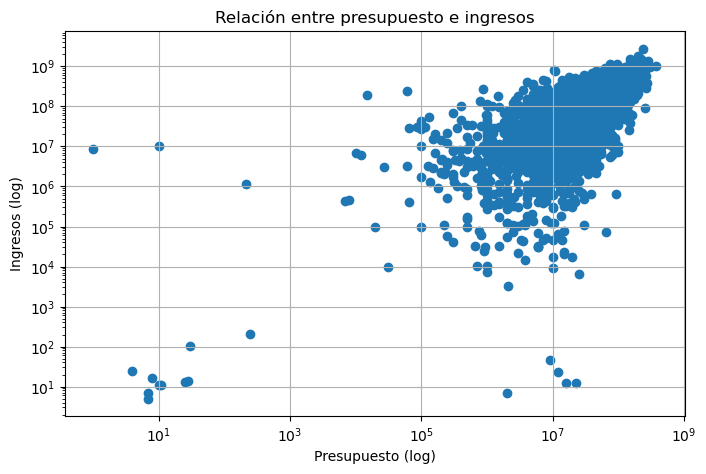

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['budget'], df['revenue'])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Presupuesto (log)')
plt.ylabel('Ingresos (log)')
plt.title('Relación entre presupuesto e ingresos')
plt.grid(True)
plt.show()



Top 10 generos con mayor ingreso

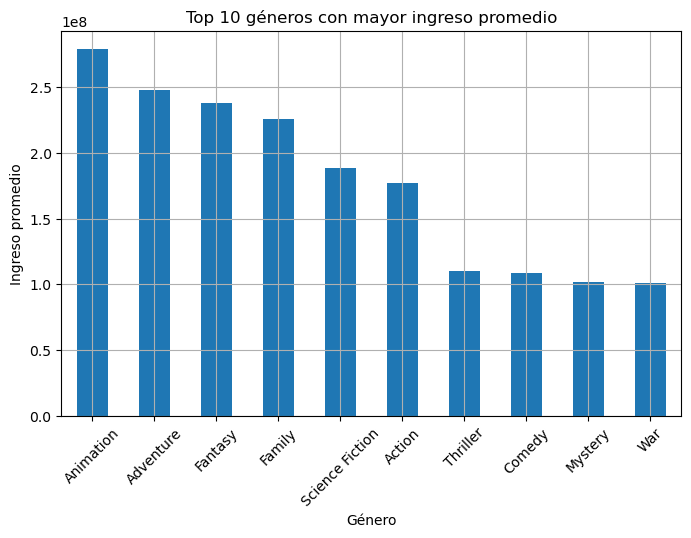

In [9]:
generos_revenue.head(10).plot(kind='bar', figsize=(8,5))
plt.title('Top 10 géneros con mayor ingreso promedio')
plt.xlabel('Género')
plt.ylabel('Ingreso promedio')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Top estudios productores con mayor ingreso promedio

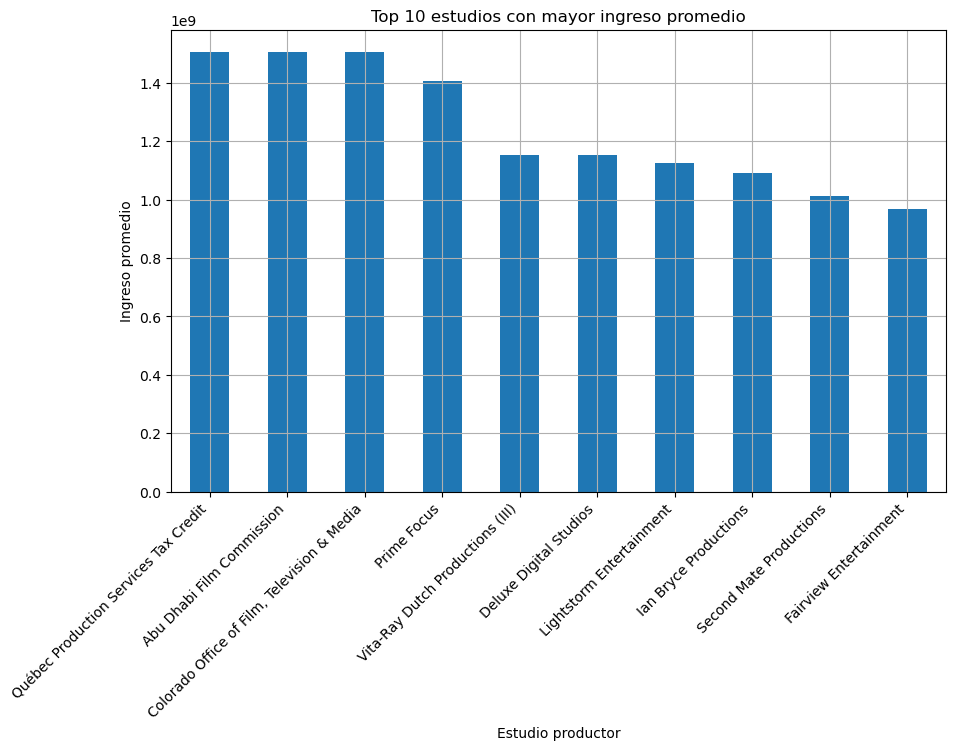

In [10]:
import ast
import matplotlib.pyplot as plt

# Convertir la columna a estructura Python real
df['production_companies'] = df['production_companies'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Extraer solo los nombres de los estudios
df['estudios_lista'] = df['production_companies'].apply(
    lambda x: [i['name'] for i in x] if isinstance(x, list) else []
)

# Separar estudios por fila
df_exploded_estudios = df.explode('estudios_lista')

# Calcular ingreso promedio por estudio
estudios_revenue = df_exploded_estudios.groupby('estudios_lista')['revenue'] \
    .mean() \
    .sort_values(ascending=False)

# Graficar top 10 estudios
plt.figure(figsize=(10,6))
estudios_revenue.head(10).plot(kind='bar')
plt.title('Top 10 estudios con mayor ingreso promedio')
plt.xlabel('Estudio productor')
plt.ylabel('Ingreso promedio')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()


Top directores con amyor ingreso promedio

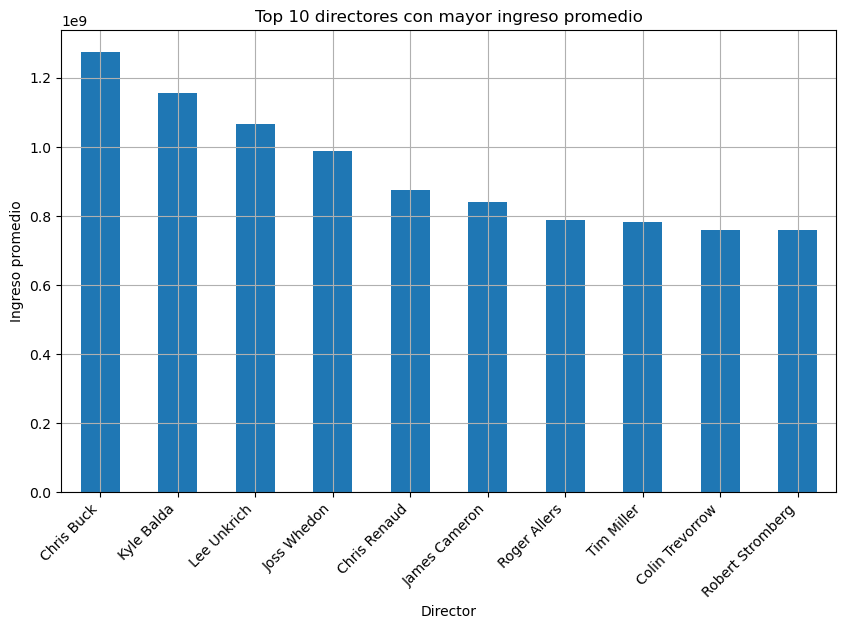

In [11]:
import matplotlib.pyplot as plt

# Agrupar por director (columna: director)
directores_revenue = df.groupby('director')['revenue'] \
    .mean() \
    .sort_values(ascending=False)

# Graficar top 10
plt.figure(figsize=(10,6))
directores_revenue.head(10).plot(kind='bar')

plt.title('Top 10 directores con mayor ingreso promedio')
plt.xlabel('Director')
plt.ylabel('Ingreso promedio')
plt.xticks(rotation=45, ha='right')
plt.grid(True)

plt.show()
